# Imports 

In [15]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# DATA LOADING

In [21]:
import os
print(os.getcwd())
print(os.listdir())

/Users/salemalmansour/Desktop/GP-CTM
['GP-CTM.ipynb', '.DS_Store', '.ipynb_checkpoints', 'Data']


In [23]:
Cells = pd.read_csv('Data/Cell-Para1d.csv')
Links = pd.read_csv('Data/Cell-NetworkData.csv')

In [25]:
Cells

,Cell ID,Qi,Ni,Delta i,X_0,cell type
0,1,9999,9999,1,0,source
1,2,9999,9999,1,0,source
2,3,9999,9999,1,0,source
3,4,9999,9999,1,0,source
4,5,9999,9999,1,0,source
...,...,...,...,...,...,...
115,116,13,17,1,0,Ordinary
116,117,99999,99999,1,0,Sink
117,118,11,26,1,0,Diverge
118,119,6,17,1,0,Diverge


In [27]:
Links

,Arc ID,FROM cell,TO cell
0,1,7,8
1,2,8,9
2,3,9,10
3,4,10,11
4,5,11,17
...,...,...,...
165,166,70,78
166,167,89,99
167,168,89,92
168,169,97,90


# Model 

In [29]:
m = gp.Model('GP-CTM') #Equal weights 
#This only removes the extra text in the output after the optimization. by changing it to 1 or commenting out it will act per usual.
m.setParam('OutputFlag',0)

Set parameter Username
Set parameter LicenseID to value 2717335
Academic license - for non-commercial use only - expires 2026-10-02


## Sets 

In [31]:
# Time Horizon 
Tmax = 360
T = list(range(0, Tmax + 1))  # 0, 1, 2, ..., 360
C = set(Cells['Cell ID'])
L = list(Links[['FROM cell ', 'TO cell ']].itertuples(index=False, name=None))


# DOWNSTREAM AND UPSTREAM 

downstream = {i: [] for i in C}
upstream   = {i: [] for i in C}
for (i,j) in L:
    downstream[i].append(j)
    upstream[j].append(i)

# CELL TYPE CLASSIFICATION 

# Sources (Demand) 
C_r = {1, 2, 3, 4, 5, 6}

# Sinks (evacuation exit points)
C_s = {14, 38, 41, 45, 117}

# Ordinary cells (1 in, 1 out)
C_o = { 8, 9, 10, 16, 17, 21, 22, 24, 25, 26, 30, 31, 33, 34, 37, 39, 42, 43, 44, 
       53, 54, 55, 58, 59, 60, 63, 64, 67, 68, 71, 72, 75, 76, 79, 80, 83, 84, 
       100, 101, 104, 105, 106, 107, 108, 109, 110, 111, 115, 116, 120}

# Merge cells (multiple in, 1 out)
C_m = {7, 12, 19, 20, 28, 32, 36, 46, 48, 51, 56, 61, 65, 69,73, 77, 82, 87, 88, 90, 92, 
       94, 96, 99, 103, 113, 114}

# Diverge cells (1 in, multiple out)
C_d = {11, 13, 15, 18, 23, 27, 29, 35, 40, 47, 49, 50, 52, 57, 62, 66, 70, 74, 78, 
       81, 85, 86, 89, 91, 93, 95, 97, 98, 102, 112, 118, 119}


# REMOVE DUPLICATES
L = list(set(L))


# CONNECTOR TYPE CLASSIFICATION

E_r = {(i,j) for (i,j) in L if i in C_r}  # Arcs FROM sources
E_s = {(i,j) for (i,j) in L if j in C_s}  # Arcs TO sinks
E_d = {(i,j) for (i,j) in L if i in C_d}  # Arcs from diverge cells
E_m = {(i,j) for (i,j) in L if j in C_m}  # Arcs to merge cells
E_o = {(i,j) for (i,j) in L if i in C_o and j in C_o}  # Ordinary-to-ordinary arcs

## Parameters

In [33]:
# Set Cells DataFrame index to Cell ID for easy lookup
Cells_indexed = Cells.set_index('Cell ID')

# Create N: Max occupancy from your Cells data
N = {(i,t): float(Cells_indexed.loc[i, 'Ni']) for i in C for t in T}


# Create Q: Flow capacity from your Cells data
Q = {(i,t): float(Cells_indexed.loc[i, 'Qi']) for i in C for t in T}

# Create delta: v/w ratio from your Cells data
delta = {(i,t): float(Cells_indexed.loc[i, 'Delta i']) for i in C for t in T}

# Create X_o: Initial occupancy from your Cells data
X_o = {i: float(Cells_indexed.loc[i, 'X_0']) for i in C}

T_0 = min(T)  # Initial time

# School demand allocation
school_demand = {
    1: 1000,
    2: 1000,
    3: 1000,
    4: 1000,
    5: 1500,
    6: 1500
}

# Total demand = 7000 vehicles
TOTAL_DEMAND = sum(school_demand.values())
MAX_DEMAND = 17  # Adjust based on your network capacity Ni at demand injection point 

# Goal targets and weights 
T_1 = 7000     # target total admitted demand over horizon
T_2 = 34300  # target total occupancy over horizon need to find the optimal target 
T_3 =7000  # target flow
# Equally weighted goals 
W_1= 4 #Demand goal 
W_2= 1 #Occupancy Goal 
W_3= 4 #Sink flow goal 

## Decision Variables 

In [35]:
X = m.addVars(C,T,lb=0.0,vtype=GRB.INTEGER, name="X") #Veh in cell i at time t 
Y = m.addVars(L,T,lb=0.0,vtype=GRB.INTEGER, name="Y") #flow of Veh from i to j at t 
D = m.addVars(C,T,lb=0.0,vtype=GRB.INTEGER, name="D") #Veh from Demand source i at t 
S_1 = m.addVar(lb=0.0, name ="S_1")   #Slack  (Goal 1)
E_2 = m.addVar(lb=0.0, name="E_2")   #Excess (Goal 2)
S_2 = m.addVar(lb=0.0, name="S_2")   #Slack (Goal 3)

### Goal Constraints

In [37]:
#Weighted GP
# --- Goal 1: admitted demand hits target with shortfall S1 ---
m.addConstr(
    gp.quicksum(D[i,t] for i in C_r for t in T) + S_1 == T_1,
    name="Goal1_Demand" #only for soucre cells 
)
# Goal 2: Total occupancy (excluding sinks for meaningful measure)
m.addConstr(
    gp.quicksum(X[i, t] for i in (C - C_s ) for t in T) - E_2 == T_2,
    name="Goal2_Occupancy"
)
# Goal 3: Only count flow through SINK connectors
m.addConstr(
    gp.quicksum(Y[i, j, t] for (i, j) in E_s for t in T) + S_2 == T_3,
    name="Goal3_SinkFlow"
)

<gurobi.Constr *Awaiting Model Update*>

## Hard constraints 

In [39]:
# --- Mass conservation for ordinary cells GOOD
for i in (C - C_r - C_s):
    for t in T:
        if t == T_0:
            continue
        m.addConstr(
            X[i, t] - X[i, t-1]
            - gp.quicksum(Y[j, i, t-1] for j in upstream[i])  # inflow  at t-1
            + gp.quicksum(Y[i, j, t-1] for j in downstream[i])    # outflow  at t-1
            == 0.0,
            name=f"Flow_bal[{i},{t}]"
        )
for i in C_r:
    for t in T:
        if t == T_0:
            continue
        m.addConstr(
            X[i, t] - X[i, t-1]
            + gp.quicksum(Y[i, j, t-1] for j in downstream[i])  # outflow at t-1 Changed to + 
            == D[i, t-1],                                       # demand admitted at t-1
            name=f"srcbal[{i},{t}]"
        )
# --- Ordinary & Source connectors (Eqs. 5–8) sending from t-1 
for (i, j) in (E_o | E_r):
    for t in T:
        m.addConstr(Y[i, j, t] <= X[i, t], name=f"Y<=X[{i},{j},{t}]")  # (5) Changed
        m.addConstr(Y[i, j, t] <= Q[(j, t)], name=f"Y<=Qj[{i},{j},{t}]")     # (6)
        m.addConstr(Y[i, j, t] <= Q[(i, t)], name=f"Y<=Qi[{i},{j},{t}]")     # (7)
        m.addConstr(
            Y[i, j, t] + delta[(j, t)] * X[j, t] <= delta[(j, t)] * N[(j, t)],  #(8)
            name=f"Prop[{i},{j},{t}]"
        )
# --- Sink connectors (Eqs. 9–10) send from t-1 for consistency ---
for (i, j) in E_s:
    for t in T:
        m.addConstr(Y[i, j, t] <= X[i, t], name=f"sink_Y<=X[{i},{j},{t}]")  # (9) Changed
        m.addConstr(Y[i, j, t] <= Q[(i, t)], name=f"sink_Y<=Qi[{i},{j},{t}]")     # (10)

# --- Diverging connector limits (Eqs. 11–12) ---
for (i, j) in E_d:
    for t in T:
        m.addConstr(Y[i, j, t] <= Q[(j, t)], name=f"Div_Y<=Qj[{i},{j},{t}]")      # (11)
        m.addConstr(
            Y[i, j, t] + delta[(j, t)] * X[j, t] <= delta[(j, t)] * N[(j, t)],
            name=f"Div_prop[{i},{j},{t}]"
        )  # (12) Changed
    

# --- Diverging nodes (Eqs. 13–14), sum send from t-1 ---
for i in C_d:
    for t in T:
        m.addConstr(gp.quicksum(Y[i, j, t] for j in downstream[i]) <= X[i, t],
                        name=f"Div_sumY<=X[{i},{t}]")                               # (13)
        m.addConstr(gp.quicksum(Y[i, j, t] for j in downstream[i]) <= Q[(i, t)],
                    name=f"Div_sumY<=Qi[{i},{t}]")                                  # (14)

# --- Merging connectors (Eqs. 15–16), send from t-1 ---
for (i, j) in E_m:
    for t in T:
        m.addConstr(Y[i, j, t] <= X[i, t], name=f"Merge_Y<=X[{i},{j},{t}]")  # (15)
        m.addConstr(Y[i, j, t] <= Q[(i, t)], name=f"Merge_Y<=Qi[{i},{j},{t}]")     # (16)receiving limit (downstream capacity)
        m.addConstr(Y[i, j, t] <= Q[(j, t)], name=f"Merge_Y<=Qj[{i},{j},{t}]") #NEW

# --- Merging nodes (Eqs. 17–18) ---
for j in C_m:
    for t in T:
        m.addConstr(
            gp.quicksum(Y[i, j, t] for i in upstream[j]) <= Q[(j, t)],
            name=f"Merge_sumY<=Qj[{j},{t}]"
        )  # (17)
        m.addConstr(
            gp.quicksum(Y[i, j, t] for i in upstream[j]) + delta[(j, t)] * X[j, t]
            <= delta[(j, t)] * N[(j, t)],
            name=f"Merge_prop[{j},{t}]"
            
        ) 
#Initial Conditions for X and Y 
T_0 = min(T)
for i in C:
    m.addConstr(X[i, T_0] == X_o[i], name=f"Init_X[{i}]") #Good 
    
for (i, j) in L:
    m.addConstr(Y[i, j, T_0] == 0.0, name=f"Init_Y[{i},{j}]") #Good 
    
#Additional constraints
# Capacity for all cells (including sources)
for i in C:
    for t in T:
        m.addConstr(X[i, t] <= N[(i, t)], name=f"Capacity[{i},{t}]")
# Demand only at sources
for i in (C - C_r):
    for t in T:
        m.addConstr(D[i, t] == 0.0, name=f"NoDemand[{i},{t}]")

# Cap maximum demand release per timestep
for i in C_r:
    for t in T:
        m.addConstr(D[i,t] <= MAX_DEMAND, name=f"max_demand_{i}_{t}")

# Each source releases its allocated demand
for i in C_r:
    m.addConstr(
        gp.quicksum(D[i, t] for t in T) == school_demand[i],
        name=f"SourceDemand[{i}]"
    )
MIN_SINK_FLOW = 500  # Each sink must receive at least 500 vehicles

for sink in C_s:
    m.addConstr(
        gp.quicksum(Y[i, sink, t] for (i,j) in E_s if j==sink for t in T) >= MIN_SINK_FLOW,
        name=f"MinSinkFlow_{sink}")

## Objective Function 

In [40]:
m.setObjective(W_1*S_1+W_2*E_2+W_3*S_2, GRB.MINIMIZE)
m.update()


# Optimize 

In [43]:
m.optimize()
if m.status == GRB.OPTIMAL:
    totD = sum(D[i, t].X for i in C_r for t in T)               # Admitted demand
    totX = sum(X[i, t].X for i in (C - C_s ) for t in T)         # Network occupancy (Goal 2 actual)
    totY_sink = sum(Y[i, j, t].X for (i, j) in E_s for t in T)  # Sink throughput C_s

    print("\n" + "=" * 60)
    print("GOAL PROGRAMMING – RESULTS")
    print("=" * 60)
    print(f"Objective (Total Deviation): {m.objVal:,.2f}\n")

    print("Goal Achievement:")
    print(f"  Goal 1 – Demand Admitted:")
    print(f"      Target = {T_1:,.0f} | Actual = {totD:,.0f} | Shortfall = {S_1.X:,.0f}")

    print(f"  Goal 2 – Network Occupancy (T₂):")
    print(f"      Target = {T_2:,.0f} | Actual = {totX:,.0f} | Excess = {E_2.X:,.0f}")

    print(f"  Goal 3 – Sink Throughput:")
    print(f"      Target = {T_3:,.0f} | Actual = {totY_sink:,.0f} | Shortfall = {S_2.X:,.0f}")

    print("=" * 60)

elif m.status == GRB.INFEASIBLE:
    print("Model is infeasible")
    m.computeIIS()
    m.write("GP_infeasible.ilp")

elif m.status == GRB.UNBOUNDED:
    print("Model is unbounded")

else:
    print(f"Optimization ended with status {m.status}")


GOAL PROGRAMMING – RESULTS
Objective (Total Deviation): 0.00

Goal Achievement:
  Goal 1 – Demand Admitted:
      Target = 7,000 | Actual = 7,000 | Shortfall = 0
  Goal 2 – Network Occupancy (T₂):
      Target = 34,300 | Actual = 34,300 | Excess = 0
  Goal 3 – Sink Throughput:
      Target = 7,000 | Actual = 7,000 | Shortfall = 0


# Save results to CSV

In [45]:

#MODEL PERFORMANCE METRICS 

data = {
    "Metric": [
        "Objective (Total Deviation)",
        "Runtime (sec)",
        "Nodes Explored",
        "Iterations (Simplex)",
        "Model Status"
    ],
    "Value": [
        round(m.ObjVal, 2),
        round(m.Runtime, 3),
        int(m.NodeCount),
        int(m.IterCount),
        m.Status
    ],
    "Explanation": [
        "Sum of weighted deviations in the GP objective function.",
        "Total wall-clock time required to solve the model.",
        "Number of nodes explored in the branch-and-bound tree.",
        "Total simplex iterations used for LP relaxations.",
        "Final model solve status (2 = OPTIMAL)."
    ]
}

# Create DataFrame
df_perf = pd.DataFrame(data)

# Display neatly
print("\n============================================================")
print("GOAL PROGRAMMING – MODEL PERFORMANCE SUMMARY")
print("============================================================")
print(df_perf.to_string(index=False))
print("============================================================")

#Save to CSV
df_perf.to_csv("GP_Model_Performance_Table.csv", index=False)


GOAL PROGRAMMING – MODEL PERFORMANCE SUMMARY
                     Metric      Value                                              Explanation
Objective (Total Deviation)      0.000 Sum of weighted deviations in the GP objective function.
              Runtime (sec)    110.852       Total wall-clock time required to solve the model.
             Nodes Explored      1.000   Number of nodes explored in the branch-and-bound tree.
       Iterations (Simplex) 195572.000        Total simplex iterations used for LP relaxations.
               Model Status      2.000                  Final model solve status (2 = OPTIMAL).


In [47]:
# Extract occupancy data
occupancy_data = [
    {"Cell": i, "Time": t, "Occupancy": X[i, t].X}
    for i in C
    for t in T
]

# Convert to DataFrame
df_occ = pd.DataFrame(occupancy_data)

# Save to CSV
df_occ.to_csv("occupancy_data_GPCTM1.csv", index=False)

In [49]:
# Extract flow data
flow_data = [
    {"From": i, "To": j, "Time": t, "Flow": Y[i, j, t].X}
    for (i, j) in L  # E is your set of links
    for t in T
]

# Convert to DataFrame
df_flow = pd.DataFrame(flow_data)

# Save to CSV
df_flow.to_csv("flow_data_GPCTM1.csv", index=False)

In [51]:
df_demand = pd.DataFrame([
    {"Source": i, "Time": t, "Demand": D[i, t].X}
    for i in C_r  # source cells
    for t in T
])
df_demand.to_csv("demand_data_GPCTM1.csv", index=False)

# Model Results 


## Gloabl metrics 

In [53]:
import pandas as pd
import numpy as np

# --- Extract demand released per source over time ---
demand_by_t = {i: [D[i, t].X for t in T] for i in C_r}
df_demand = pd.DataFrame(demand_by_t)
df_demand.index = T  # timesteps as index

# --- Group every 10 minutes (60 timesteps × 10s each = 10min) ---
chunk_size = 60
grouped = df_demand.groupby(df_demand.index // chunk_size).sum()
grouped.index = grouped.index * chunk_size / 6  # convert to minutes

# --- Round and clean up ---
grouped = grouped.round(1)
grouped.index.name = "Time (minutes)"

# --- Add a total column across all sources for each time chunk ---
grouped["Total (All Sources)"] = grouped.sum(axis=1)

# --- Add a final total row ---
grouped.loc["Total Released"] = grouped.sum()

# --- Display nicely formatted table ---
print("============================================================")
print("DEMAND RELEASE SCHEDULE PER SOURCE (GP-Optimized, 10-Minute Chunks)")
print("============================================================")
display(grouped.style.set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).format("{:,.0f}"))


DEMAND RELEASE SCHEDULE PER SOURCE (GP-Optimized, 10-Minute Chunks)


,1,2,3,4,5,6,Total (All Sources)
Time (minutes),,,,,,,
0.000000,256,146,189,166,229,228,"1,214"
10.000000,131,157,209,128,243,234,"1,102"
20.000000,182,176,70,197,276,231,"1,132"
30.000000,164,189,159,109,250,332,"1,203"
40.000000,143,178,164,214,241,245,"1,185"
50.000000,124,154,209,186,261,230,"1,164"
60.000000,0,0,0,0,0,0,0
Total Released,"1,000","1,000","1,000","1,000","1,500","1,500","7,000"


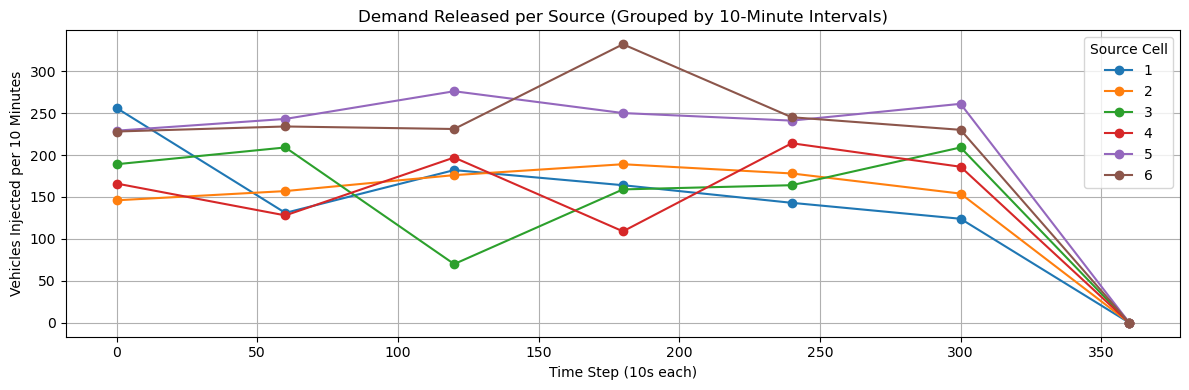

In [55]:
# Load the demand data
df_demand = pd.read_csv("demand_data_GPCTM1.csv")

# Pivot so each source cell becomes a column, indexed by time
demand_df = df_demand.pivot(index="Time", columns="Source", values="Demand")

# Group demand by 10-minute intervals (60 time steps = 600 sec)w
grouped_demand_10min = demand_df.groupby(demand_df.index // 60).sum()
grouped_demand_10min.index = grouped_demand_10min.index * 60  # Convert back to time steps

# Plot
plt.figure(figsize=(12, 4))
grouped_demand_10min.plot(marker='o', ax=plt.gca())
plt.title("Demand Released per Source (Grouped by 10-Minute Intervals)")
plt.xlabel("Time Step (10s each)")
plt.ylabel("Vehicles Injected per 10 Minutes")
plt.legend(title="Source Cell")
plt.grid(True)
plt.tight_layout()

plt.savefig("Demand_Release_Per_Source_GPCTM1.pdf", bbox_inches='tight')

plt.show()

SOURCE CELL OCCUPANCY SUMMARY
                        Metric Value
Average Source Occupancy (veh)  14.6
   Peak Source Occupancy (veh)  29.0
  Time of Peak Occupancy (min)  39.7


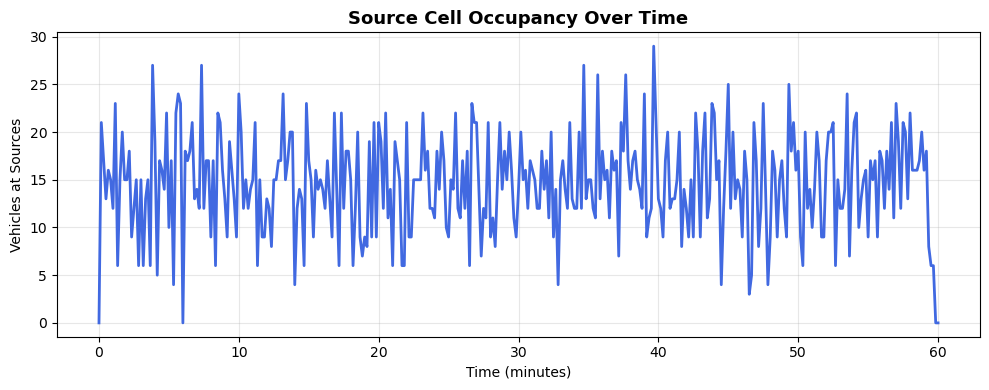

In [57]:
import pandas as pd


# SOURCE CELL OCCUPANCY ANALYSIS


# --- Extract occupancy for only source cells over time ---
source_occ = [sum(X[i, t].X for i in C_r) for t in T]   # total occupancy across all source cells
time_minutes = [t * 10 / 60 for t in T]                 # convert 10s steps → minutes

# --- Compute summary statistics ---
avg_occ_sources = sum(source_occ) / len(source_occ)
max_occ_sources = max(source_occ)
t_peak_idx = source_occ.index(max_occ_sources)
t_peak_min = time_minutes[t_peak_idx]


# DISPLAY SUMMARY

source_occ_summary = pd.DataFrame({
    "Metric": [
        "Average Source Occupancy (veh)",
        "Peak Source Occupancy (veh)",
        "Time of Peak Occupancy (min)"
    ],
    "Value": [
        f"{avg_occ_sources:,.1f}",
        f"{max_occ_sources:,.1f}",
        f"{t_peak_min:.1f}"
    ]
})

print("=" * 60)
print("SOURCE CELL OCCUPANCY SUMMARY")
print("=" * 60)
print(source_occ_summary.to_string(index=False))
print("=" * 60)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(time_minutes, source_occ, linewidth=2, color='royalblue')
plt.title("Source Cell Occupancy Over Time", fontsize=13, fontweight='bold')
plt.xlabel("Time (minutes)")
plt.ylabel("Vehicles at Sources")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Source_Occupancy_Over_Time.pdf", bbox_inches='tight')
plt.show()

In [59]:
import pandas as pd


# GP-CTM PERFORMANCE SUMMARY TABLE


print("=== GP-CTM MODEL (T=360) ===")

# --- Compute metrics ---
total_gp_demand = sum(D[i, t].x for i in C_r for t in T)
total_gp_evacuated = sum(Y[i, j, t].x for (i, j) in E_s for t in T)
avg_at_sources_gp = sum(X[i, t].x for i in C_r for t in T) / len(T)
total_gp_occupancy = sum(X[i, t].x for i in (C - C_s) for t in T)
still_at_sources = sum(X[i, 360].x for i in C_r)

# --- Create DataFrame ---
data = {
    "Metric": [
        "Total Demand Released",
        "Total Evacuated (Sink Throughput)",
        "Evacuation Rate (%)",
        "Average Waiting at Sources",
        "Total Network Occupancy",
        "Vehicles Remaining at Sources (t=360)"
    ],
    "Value": [
        f"{total_gp_demand:,.0f}",
        f"{total_gp_evacuated:,.0f}",
        f"{(total_gp_evacuated / total_gp_demand * 100):.1f}%",
        f"{avg_at_sources_gp:,.0f}",
        f"{total_gp_occupancy:,.0f}",
        f"{still_at_sources:,.0f}"
    ]
}

df_gp_summary = pd.DataFrame(data)

# --- Display neatly ---
print("\n============================================================")
print("GP-CTM MODEL PERFORMANCE SUMMARY")
print("============================================================")
print(df_gp_summary.to_string(index=False))
print("============================================================")

# --- Save outputs ---
df_gp_summary.to_csv("GPCTM_Performance_Summary.csv", index=False)
df_gp_summary.to_markdown("GPCTM_Performance_Summary.md", index=False)

=== GP-CTM MODEL (T=360) ===

GP-CTM MODEL PERFORMANCE SUMMARY
                               Metric  Value
                Total Demand Released  7,000
    Total Evacuated (Sink Throughput)  7,000
                  Evacuation Rate (%) 100.0%
           Average Waiting at Sources     15
              Total Network Occupancy 34,300
Vehicles Remaining at Sources (t=360)      0


## Temporal Metrics 

In [61]:
import pandas as pd
# OCCUPANCY ANALYSIS

# --- 1. Instantaneous occupancy at each timestep (exclude sources & sinks) ---
inst_occ = [sum(X[i, t].X for i in (C - C_s - C_r)) for t in T]

# --- 2. Convert time to minutes (Δt = 10 sec) ---
time_minutes = [t * 10 / 60 for t in T]

# --- 3. Early-period (first 10 min = first 60 steps) stats ---
first_10min_occ = inst_occ[:60]
avg_first10 = sum(first_10min_occ) / len(first_10min_occ)
max_first10 = max(first_10min_occ)

# --- 4. Peak occupancy overall ---
max_occ = max(inst_occ)
t_peak_idx = inst_occ.index(max_occ)
t_peak_min = time_minutes[t_peak_idx]

# --- 5. Average occupancy (entire simulation) ---
avg_all_time = sum(inst_occ) / len(inst_occ)

# ============================================================
# CREATE TABLE
# ============================================================
data = {
    "Metric": [
        "Average Occupancy (First 10 Minutes)",
        "Peak Occupancy (First 10 Minutes)",
        "Average Occupancy (All Time)",
        "Peak Occupancy (Overall)",
        "Time of Peak Occupancy (Minutes)",
        "Time Step of Peak Occupancy"
    ],
    "Value": [
        f"{avg_first10:,.1f}",
        f"{max_first10:,.1f}",
        f"{avg_all_time:,.1f}",
        f"{max_occ:,.1f}",
        f"{t_peak_min:.1f}",
        f"{t_peak_idx}"
    ]
}

df_occ_summary = pd.DataFrame(data)

# ============================================================
# DISPLAY & SAVE
# ============================================================
print("\n" + "="*65)
print("NETWORK OCCUPANCY SUMMARY TABLE")
print("="*65)
print(df_occ_summary.to_string(index=False))
print("="*65)

# Save results
df_occ_summary.to_csv("Network_Occupancy_Summary.csv", index=False)
df_occ_summary.to_markdown("Network_Occupancy_Summary.md", index=False)


NETWORK OCCUPANCY SUMMARY TABLE
                              Metric Value
Average Occupancy (First 10 Minutes)  79.0
   Peak Occupancy (First 10 Minutes) 110.0
        Average Occupancy (All Time)  80.4
            Peak Occupancy (Overall) 131.0
    Time of Peak Occupancy (Minutes)  14.0
         Time Step of Peak Occupancy    84


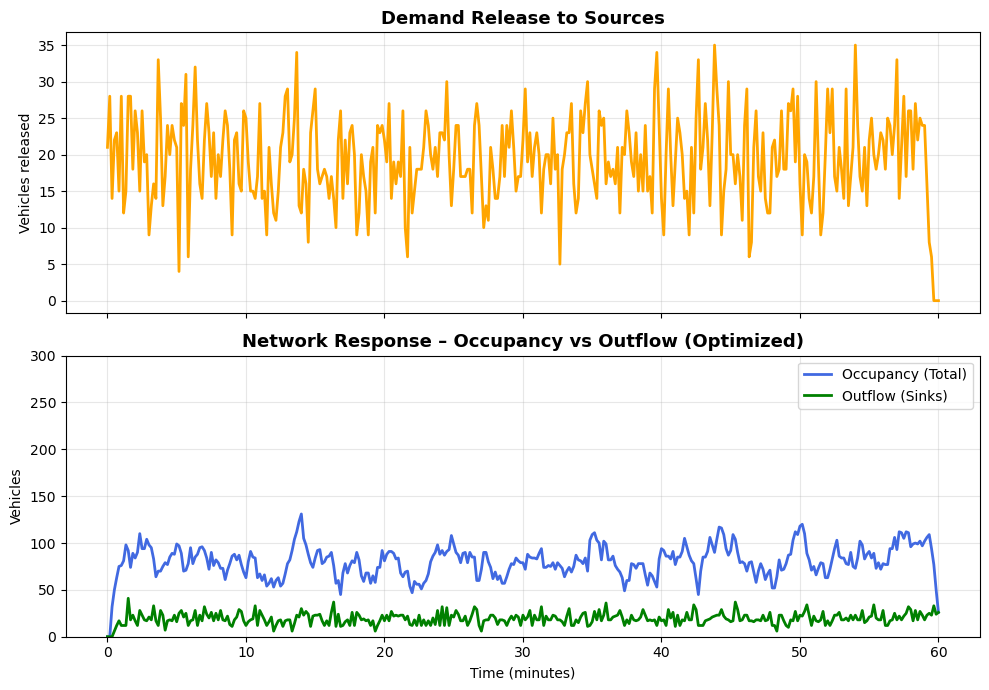

In [63]:
import matplotlib.pyplot as plt

# --- Compute each component ---
inflow  = [sum(D[i, t].X for i in C_r) for t in T]               # demand released
outflow = [sum(Y[i, j, t].X for (i, j) in E_s) for t in T]       # vehicles exiting
occupancy = [sum(X[i, t].X for i in (C - C_r - C_s)) for t in T] # vehicles inside

# --- Convert timesteps to minutes (Δt = 10 sec) ---
time_min = [t * 10 / 60 for t in T]

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- (A) INFLOW ---
axes[0].plot(time_min, inflow, color='orange', linewidth=2, label='Demand release')
axes[0].set_title("Demand Release to Sources", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Vehicles released")
axes[0].grid(True, alpha=0.3)
axes[0].grid(True, alpha=0.3)



# --- (B) OCCUPANCY + OUTFLOW ---
axes[1].plot(time_min, occupancy, color='royalblue', linewidth=2, label='Occupancy (Total)')
axes[1].plot(time_min, outflow, color='green', linewidth=2, label='Outflow (Sinks)')
axes[1].set_title("Network Response – Occupancy vs Outflow (Optimized)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Time (minutes)")
axes[1].set_ylabel("Vehicles")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.ylim(0, 300) 
plt.tight_layout()


plt.show()

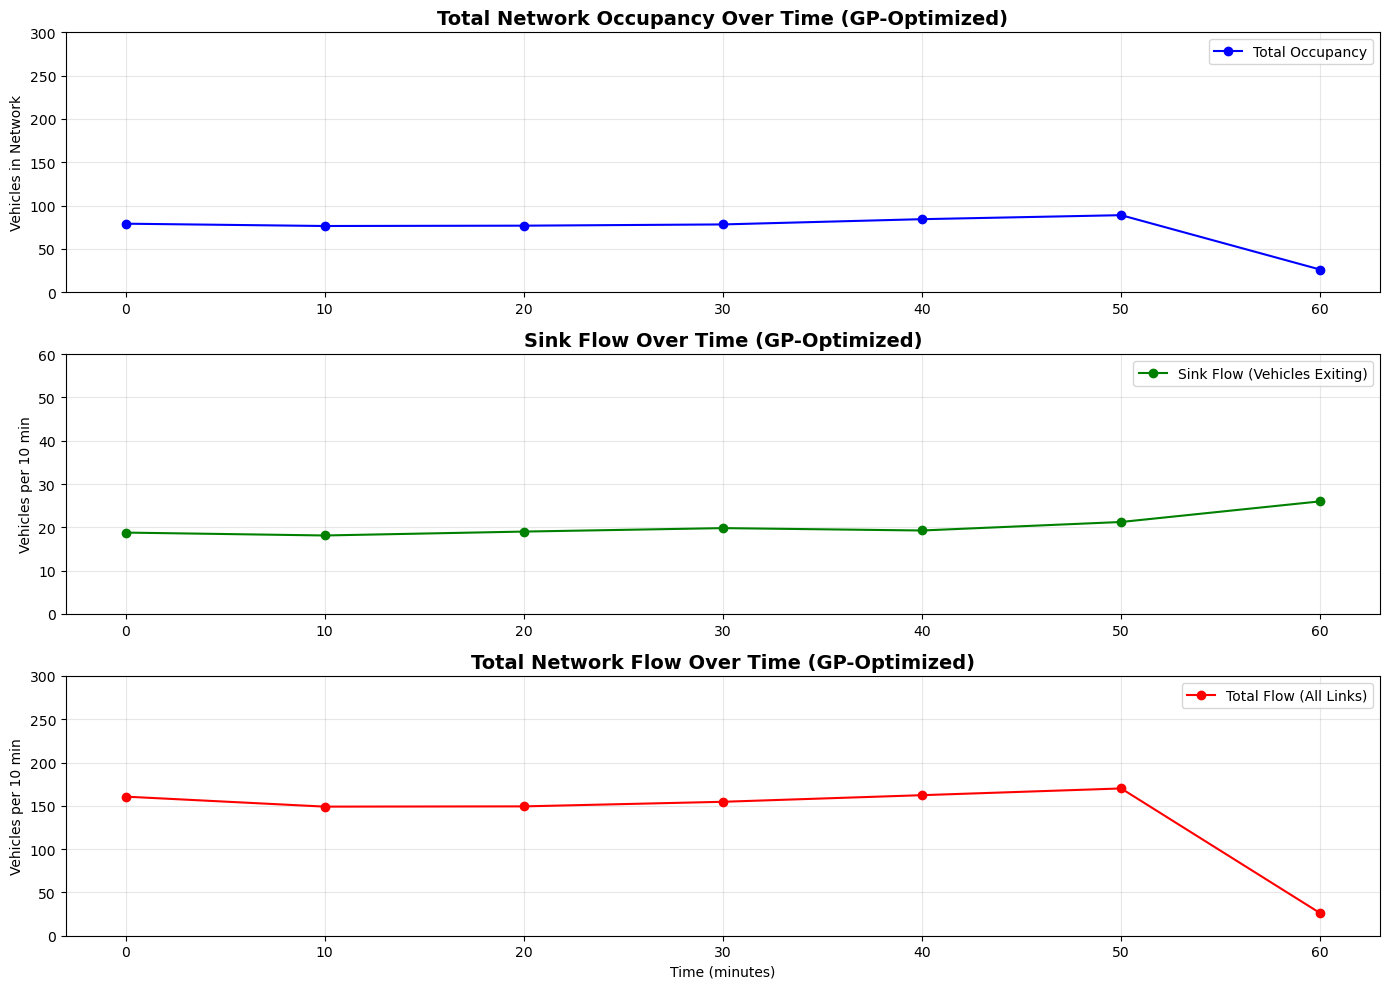

Tip: define baseline_avg_occ = <value from baseline> to auto-compute efficiency.


In [65]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GOAL PROGRAMMING (OPTIMIZED RELEASE) PERFORMANCE ANALYSIS
# ============================================================

# --- 1. Total Occupancy per timestep ---
occ_by_t = [sum(X[i, t].X for i in (C - C_s-C_r)) for t in T]

# --- 2. Sink Flow per timestep (sum of all sink arcs) ---
sink_flow_by_t = [sum(Y[i, j, t].X for (i, j) in E_s) for t in T]

# --- 3. Total Flow in Network (all arcs) ---
flow_by_t = [sum(Y[i, j, t].X for (i, j) in L) for t in T]

# --- Convert to 10-minute chunks (60 timesteps if Δt = 10s) ---
chunk_size = 60
chunks = np.arange(0, len(T), chunk_size)

def chunk_avg(data):
    return [np.mean(data[t:t+chunk_size]) for t in chunks]

occ_chunked = chunk_avg(occ_by_t)
sink_chunked = chunk_avg(sink_flow_by_t)
flow_chunked = chunk_avg(flow_by_t)
chunk_labels = [t/6 for t in chunks]  # convert timestep → minutes

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(14, 10))

# ---- (A) Occupancy ----
plt.subplot(3, 1, 1)
plt.plot(chunk_labels, occ_chunked, 'b-o', label='Total Occupancy')
plt.title("Total Network Occupancy Over Time (GP-Optimized)", fontsize=14, fontweight='bold')
plt.ylabel("Vehicles in Network")
plt.grid(True, alpha=0.3)
plt.ylim(0, 300) 
plt.legend()


# ---- (B) Sink Flow ----
plt.subplot(3, 1, 2)
plt.plot(chunk_labels, sink_chunked, 'g-o', label='Sink Flow (Vehicles Exiting)')
plt.title("Sink Flow Over Time (GP-Optimized)", fontsize=14, fontweight='bold')
plt.ylabel("Vehicles per 10 min")
plt.grid(True, alpha=0.3)
plt.ylim(0, 60) 
plt.legend()

# ---- (C) Total Flow ----
plt.subplot(3, 1, 3)
plt.plot(chunk_labels, flow_chunked, 'r-o', label='Total Flow (All Links)')
plt.title("Total Network Flow Over Time (GP-Optimized)", fontsize=14, fontweight='bold')
plt.xlabel("Time (minutes)")
plt.ylabel("Vehicles per 10 min")
plt.grid(True, alpha=0.3)
plt.ylim(0, 300) 
plt.legend()

plt.tight_layout()


plt.savefig("Global-Occ-Sink-Flow-GPCTM1.pdf", bbox_inches='tight')
plt.show()

try:
    improvement = (1 - avg_occ / baseline_avg_occ) * 100
    print(f"Average occupancy reduced by {improvement:.1f}% compared to baseline.")
except NameError:
    print("Tip: define baseline_avg_occ = <value from baseline> to auto-compute efficiency.")

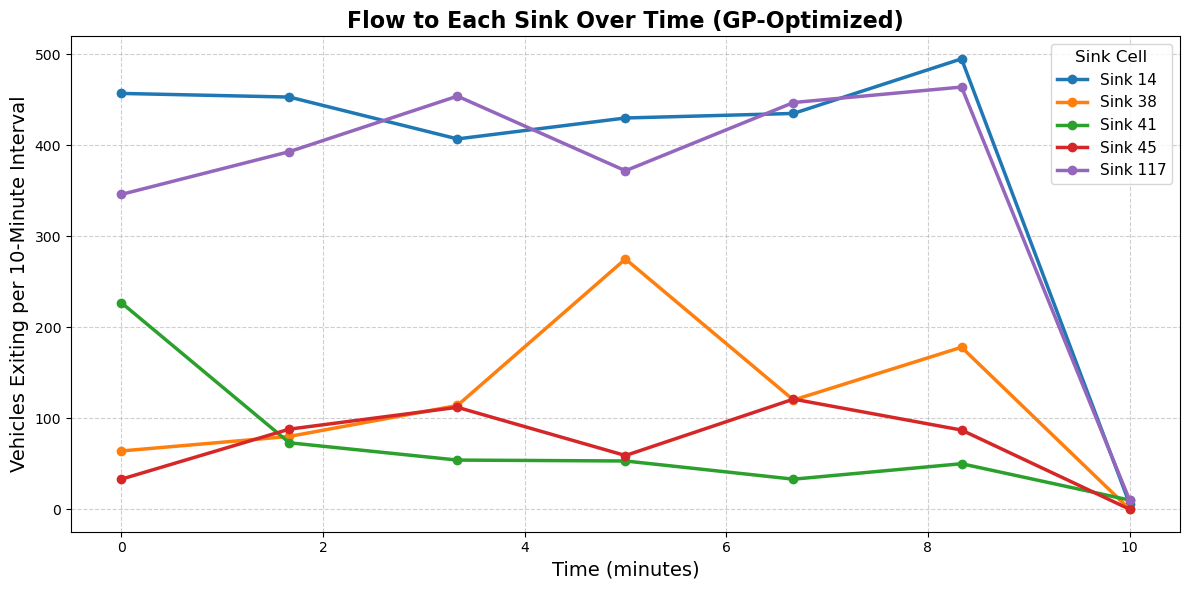

In [69]:
# Make sure your model is solved first
if m.status == GRB.OPTIMAL:
    
    sink_flows = []
    for (i, j) in E_s:           # all arcs going into sink cells
        for t in T:
            sink_flows.append({
                "From": i,
                "To": j,
                "Time": t,
                "Flow": Y[i, j, t].X
            })
    
    # Create DataFrame
    flow_df = pd.DataFrame(sink_flows)
    
    # ============================================================
    # 2. AGGREGATE BY 10-MINUTE INTERVALS
    # ============================================================
    
    chunk_size = 60  # 60 time steps = 10 minutes if Δt = 10s
    
    grouped = flow_df.groupby(["To", "Time"])["Flow"].sum().unstack(fill_value=0)
    grouped_10min = grouped.T.groupby(grouped.columns // chunk_size).sum().T
    grouped_10min.columns = grouped_10min.columns * 10 / 6  # convert to minutes
    
    # ============================================================
    # 3. PLOT
    # ============================================================
    plt.figure(figsize=(12, 6))
    
    for sink in grouped_10min.index:
        plt.plot(
            grouped_10min.columns,
            grouped_10min.loc[sink],
            marker="o",
            linewidth=2.5,
            label=f"Sink {sink}"
        )
    
    plt.title("Flow to Each Sink Over Time (GP-Optimized)", fontsize=16, fontweight="bold")
    plt.xlabel("Time (minutes)", fontsize=14)
    plt.ylabel("Vehicles Exiting per 10-Minute Interval", fontsize=14)
    plt.legend(title="Sink Cell", fontsize=11, title_fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("Temporal-Optimized_sink_flow.png", bbox_inches='tight')
    plt.show()
    

else:
    print("Model not solved yet or infeasible.")

In [71]:
import pandas as pd

# ============================================================
# FLOW THROUGH EACH SINK (Total Evacuated per Sink)
# ============================================================

# --- Compute total flow for each sink ---
sink_data = []
for sink in C_s:
    total_flow = sum(Y[i, sink, t].x for (i, j) in E_s if j == sink for t in T)
    sink_data.append({"Sink": sink, "Total_Flow": total_flow})

# --- Convert to DataFrame ---
df_sink_flow = pd.DataFrame(sink_data)

# --- Sort descending by total flow ---
df_sink_flow = df_sink_flow.sort_values(by="Total_Flow", ascending=False).reset_index(drop=True)

# --- Display table in notebook ---
print("=" * 60)
print("TOTAL FLOW THROUGH EACH SINK (Aggregated Across Time)")
print("=" * 60)
print(df_sink_flow.to_string(index=False))
print("=" * 60)


TOTAL FLOW THROUGH EACH SINK (Aggregated Across Time)
 Sink  Total_Flow
   14      2683.0
  117      2486.0
   38       831.0
   41       500.0
   45       500.0


## Spatial Metrics 

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GENERATE top_bottlenecks_gp IF NOT DEFINED
# ============================================================

# Example: find top 10 most utilized (or congested) cells
# Make sure `util_df_chunked_gp` exists and contains columns:
# ['Cell', 'Time_Min', 'Utilization']

# Step 1. Compute average utilization per cell
avg_util_per_cell = (
    util_df_chunked_gp.groupby('Cell')['Utilization']
    .mean()
    .reset_index()
    .sort_values(by='Utilization', ascending=False)
)

# Step 2. Rename for clarity
top_bottlenecks_gp = avg_util_per_cell.rename(columns={'Utilization': 'Avg_Utilization'})

# Step 3. Verify the top cells
print("Top 10 bottlenecks (by average utilization):")
print(top_bottlenecks_gp.head(10).to_string(index=False))

# ============================================================
# SPLIT INTO GROUPS & PLOT
# ============================================================

top10_cells = top_bottlenecks_gp['Cell'].head(10).tolist()
top10_cells.sort()

group1 = sorted(top10_cells[:5])   # Cells 1–5
group2 = sorted(top10_cells[5:10]) # Cells 6–10

def plot_bottlenecks(cell_list, title_suffix, filename):
    plt.figure(figsize=(12, 6))

    for cell in sorted(cell_list):
        subset = util_df_chunked_gp[util_df_chunked_gp['Cell'] == cell]
        plt.plot(
            subset['Time_Min'],
            subset['Utilization'],
            linewidth=2,
            marker='o',
            markersize=4,
            label=f'Cell {cell}'
        )

    plt.title(f"Average Utilization (10-Minute Intervals) for Bottleneck Cells {title_suffix}",
              fontsize=14, fontweight='bold')
    plt.xlabel("Time (minutes)", fontsize=12)
    plt.ylabel(r"Average Utilization ($\frac{X_{i,t}}{N_{i,t}}$)", fontsize=15)
    plt.ylim(0, 1.05)

    plt.axhline(y=0.8, color='orange', linestyle='--', linewidth=1.3, label='80% Threshold')
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Full Capacity')

    plt.legend(title="Cell ID", fontsize=10, bbox_to_anchor=(1.02, 0.5),
               loc='center left', borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    #plt.savefig(filename, bbox_inches='tight')
    plt.show()

# --- Plot group 1 (Cells 1–5) ---
plot_bottlenecks(group1, "(Cells 1–5)", "Utilization_TopCells_1to5.pdf")

# --- Plot group 2 (Cells 6–10) ---
plot_bottlenecks(group2, "(Cells 6–10)", "Utilization_TopCells_6to10.pdf")


NameError: name 'util_df_chunked_gp' is not defined

In [75]:
import pandas as pd
#top 10 bottle necks 

# --- Prepare table ---
table_bottlenecks_gp = top_bottlenecks_gp.copy().round({
    "avg_util": 2,
    "max_util": 2,
    "over_80": 1,
    "over_90": 1
})

# Rename columns for readability
table_bottlenecks_gp.rename(columns={
    "Cell": "Cell ID",
    "avg_util": "Avg Utilization",
    "max_util": "Max Utilization",
    "over_80": "% Time > 80%",
    "over_90": "% Time > 90%"
}, inplace=True)

# Add ranking (1–10)
table_bottlenecks_gp.insert(0, "Rank", range(1, len(table_bottlenecks_gp) + 1))

# ============================================================
# 1. TEXT (Terminal Style)
# ============================================================
text_output = (
    "=" * 80 + "\n"
    + "TOP 10 BOTTLENECK CELLS (Highest Average Utilization) – GP Optimized\n"
    + "=" * 80 + "\n\n"
    + table_bottlenecks_gp.to_string(index=False)
    + "\n\n" + "=" * 80
)

with open("Top10_Bottlenecks_GPCTM.txt", "w") as f:
    f.write(text_output)

print(text_output)

# ============================================================
# 2. MARKDOWN
# ============================================================
md_output = (
    "## TOP 10 BOTTLENECK CELLS (Highest Average Utilization) – GP Optimized\n\n"
    + table_bottlenecks_gp.to_markdown(index=False)
)

with open("Top10_Bottlenecks_GPCTM.md", "w") as f:
    f.write(md_output)

# ============================================================
# 3. CSV
# ============================================================
table_bottlenecks_gp.to_csv("Top10_Bottlenecks_GPCTM.csv", index=False)


NameError: name 'top_bottlenecks_gp' is not defined